**Installing the necessary packages**

In [ ]:
install.packages ("sqldf")
install.packages ("ggplot2")

Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)

also installing the dependencies ‘gsubfn’, ‘proto’, ‘RSQLite’, ‘chron’


Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)



**Loading the library sqldf & ggplot2**

In [ ]:
library (sqldf)
library (ggplot2)

**Load the necessary dataset in this case all of the datasets within north_dataset**

In [ ]:
orders     <- read.csv("/content/northstar-analytics/north_dataset/orders.csv",     stringsAsFactors = FALSE)
deliveries <- read.csv("/content/northstar-analytics/north_dataset/deliveries.csv", stringsAsFactors = FALSE)
complaints <- read.csv("/content/northstar-analytics/north_dataset/complaints.csv", stringsAsFactors = FALSE)
customers  <- read.csv("/content/northstar-analytics/north_dataset/customers.csv",  stringsAsFactors = FALSE)
drivers    <- read.csv("/content/northstar-analytics/north_dataset/drivers.csv",    stringsAsFactors = FALSE)
hubs       <- read.csv("/content/northstar-analytics/north_dataset/hubs.csv",       stringsAsFactors = FALSE)
vehicles   <- read.csv("/content/northstar-analytics/north_dataset/vehicles.csv",   stringsAsFactors = FALSE)
incidents  <- read.csv("/content/northstar-analytics/north_dataset/incidents.csv",  stringsAsFactors = FALSE)

cat("Successfully loaded all the files from north_dataset\n")

Successfully loaded all the files from north_dataset


**Doing the necessary check of the dataset**

In [ ]:
cat("Orders shape:    ", nrow(orders),     "rows,", ncol(orders),     "columns\n")
cat("Deliveries shape:", nrow(deliveries), "rows,", ncol(deliveries), "columns\n")
cat("Complaints shape:", nrow(complaints), "rows,", ncol(complaints), "columns\n")
cat("Customers shape: ", nrow(customers),  "rows,", ncol(customers),  "columns\n")

Orders shape:     1250 rows, 11 columns
Deliveries shape: 950 rows, 13 columns
Complaints shape: 320 rows, 10 columns
Customers shape:  650 rows, 9 columns


**Cleaning the zone before going any further with querying**

In [ ]:
clean_zone <- function(x) {
  x <- tolower(trimws(x))
  x <- gsub("^airport$", "Airport",   x)
  x <- gsub("^north$",   "North",     x)
  x <- gsub("^south$",   "South",     x)
  x <- gsub("^east$",    "East",      x)
  x <- gsub("^west$",    "West",      x)
  x <- gsub("^central$|^ctr$", "Central", x)
  x <- gsub("^riverside$", "RiverSide", x)
  return(x)
}

In [ ]:
orders$pickup_zone    <- clean_zone(orders$pickup_zone)
orders$dropoff_zone   <- clean_zone(orders$dropoff_zone)
drivers$base_zone     <- clean_zone(drivers$base_zone)
customers$home_zone   <- clean_zone(customers$home_zone)

cat("The zone names standardised.\n")

The zone names standardised.


**1st Query: Identifying the Delivery Failure Rate by Pickup Zone**

We want to understand which zones have the most failed or delayed deliveries. This helps pinpoint underperforming city areas that management flagged as a concern.

In [ ]:
q1 <- sqldf("
  SELECT
    o.pickup_zone,
    COUNT(d.delivery_id) AS total_deliveries,
    SUM(CASE WHEN d.delivery_status = 'Failed'  THEN 1 ELSE 0 END) AS failed,
    SUM(CASE WHEN d.delivery_status = 'Delayed' THEN 1 ELSE 0 END) AS delayed,
    SUM(CASE WHEN d.delivery_status = 'OnTime'  THEN 1 ELSE 0 END) AS on_time,
    ROUND(
      100.0 * SUM(CASE WHEN d.delivery_status IN ('Failed','Delayed') THEN 1 ELSE 0 END)
      / COUNT(d.delivery_id), 2
    ) AS failure_rate_pct
  FROM deliveries d
  JOIN orders o ON d.order_id = o.order_id
  GROUP BY o.pickup_zone
  ORDER BY failure_rate_pct DESC
")

cat("\n Query 1: Delivery Failure Rate by Pickup Zone \n\n")
print(q1)


 Query 1: Delivery Failure Rate by Pickup Zone 

  pickup_zone total_deliveries failed delayed on_time failure_rate_pct
1     Central              174     33      51      90            48.28
2     Airport              113     12      31      70            38.05
3   RiverSide              119     18      25      76            36.13
4        East              156     19      31     106            32.05
5       North              135     22      21      92            31.85
6        West              114     14      21      79            30.70
7       South              139     14      22     103            25.90


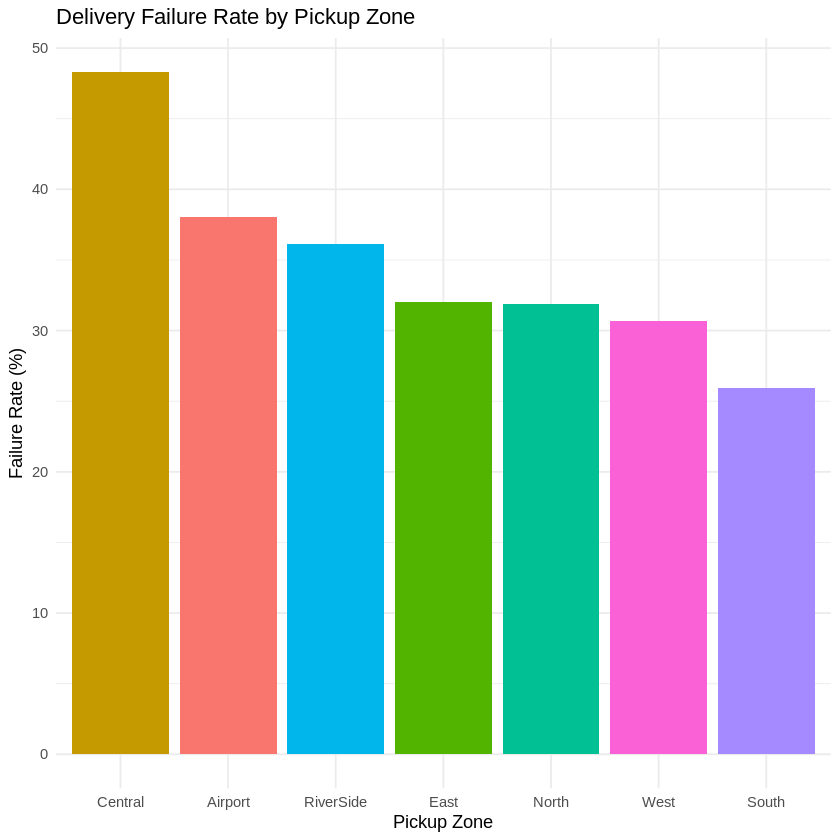

In [ ]:
# Vizualization

ggplot(q1, aes(x = reorder(pickup_zone, -failure_rate_pct), y = failure_rate_pct, fill = pickup_zone)) +
  geom_bar(stat = "identity") +
  labs(
    title = "Delivery Failure Rate by Pickup Zone",
    x     = "Pickup Zone",
    y     = "Failure Rate (%)"
  ) +
  theme_minimal() +
  theme(legend.position = "none")

**2nd QUERY: Top 10 Drivers by Average Customer Rating**

Identifying high-performing drivers helps the management understand what good service looks like and where to direct training investment.


In [ ]:
q2 <- sqldf("
  SELECT
    d.driver_id,
    dr.base_zone,
    dr.employment_type,
    dr.training_score,
    COUNT(d.delivery_id) AS total_deliveries,
    ROUND(AVG(d.customer_rating_post_delivery), 2)  AS avg_rating
  FROM deliveries d
  JOIN drivers dr ON d.driver_id = dr.driver_id
  GROUP BY d.driver_id
  HAVING total_deliveries >= 3
  ORDER BY avg_rating DESC
  LIMIT 10
")

cat("\n Query 2: Top 10 Drivers by Customer Rating \n\n")
print(q2)


 Query 2: Top 10 Drivers by Customer Rating 

   driver_id base_zone employment_type training_score total_deliveries
1       D122     South        FullTime           63.5                3
2       D118     North        FullTime           80.6                4
3       D025     North        FullTime           86.4                3
4       D061 RiverSide        Contract           85.9                4
5       D015      East        FullTime           85.1                6
6       D013      West        FullTime           80.8                4
7       D003   Airport        FullTime           96.5                4
8       D138   Central        PartTime           69.2                4
9       D126      East        PartTime           69.7                5
10      D014     North        FullTime           76.1                4
   avg_rating
1        4.72
2        4.66
3        4.65
4        4.61
5        4.52
6        4.52
7        4.45
8        4.44
9        4.43
10       4.43


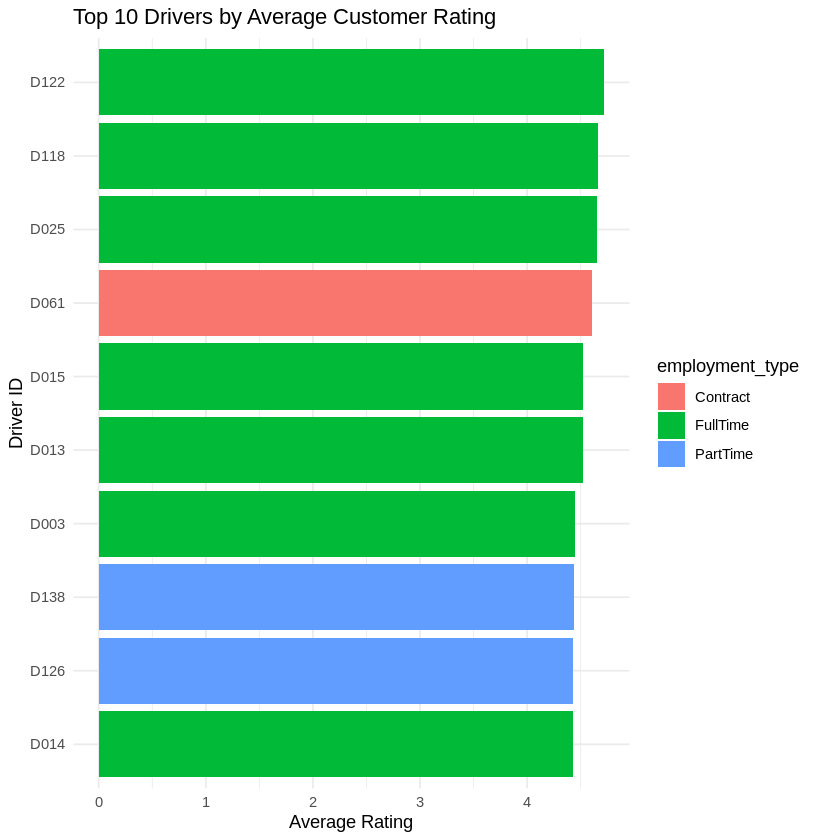

In [ ]:
ggplot(q2, aes(x = reorder(driver_id, avg_rating), y = avg_rating, fill = employment_type)) +
  geom_bar(stat = "identity") +
  coord_flip() +
  labs(
    title = "Top 10 Drivers by Average Customer Rating",
    x     = "Driver ID",
    y     = "Average Rating"
  ) +
  theme_minimal()

**3rd QUERY: Complaint Volume and Average Compensation by Type**

Breaking down complaints by type reveals which service failures are most common and most costly to resolve.

In [ ]:
q3 <- sqldf("
  SELECT
    complaint_type,
    COUNT(complaint_id)              AS total_complaints,
    SUM(CASE WHEN severity = 'High'   THEN 1 ELSE 0 END) AS high_severity,
    SUM(CASE WHEN severity = 'Medium' THEN 1 ELSE 0 END) AS medium_severity,
    SUM(CASE WHEN severity = 'Low'    THEN 1 ELSE 0 END) AS low_severity,
    ROUND(AVG(compensation_amount), 2) AS avg_compensation_gbp
  FROM complaints
  GROUP BY complaint_type
  ORDER BY total_complaints DESC
")

cat("\n Query 3: Complaints by Type and Severity \n\n")

print(q3)


 Query 3: Complaints by Type and Severity 

     complaint_type total_complaints high_severity medium_severity low_severity
1             Delay              101            18              56           27
2      MissedPickup               64            16              37           11
3          AppIssue               53            13              25           15
4   DriverBehaviour               51            16              31            4
5 SupportExperience               20             3              12            5
6           Billing               16             4               9            3
7            Damage               15             7               2            6
  avg_compensation_gbp
1                18.05
2                22.59
3                19.61
4                21.15
5                17.13
6                23.87
7                23.98


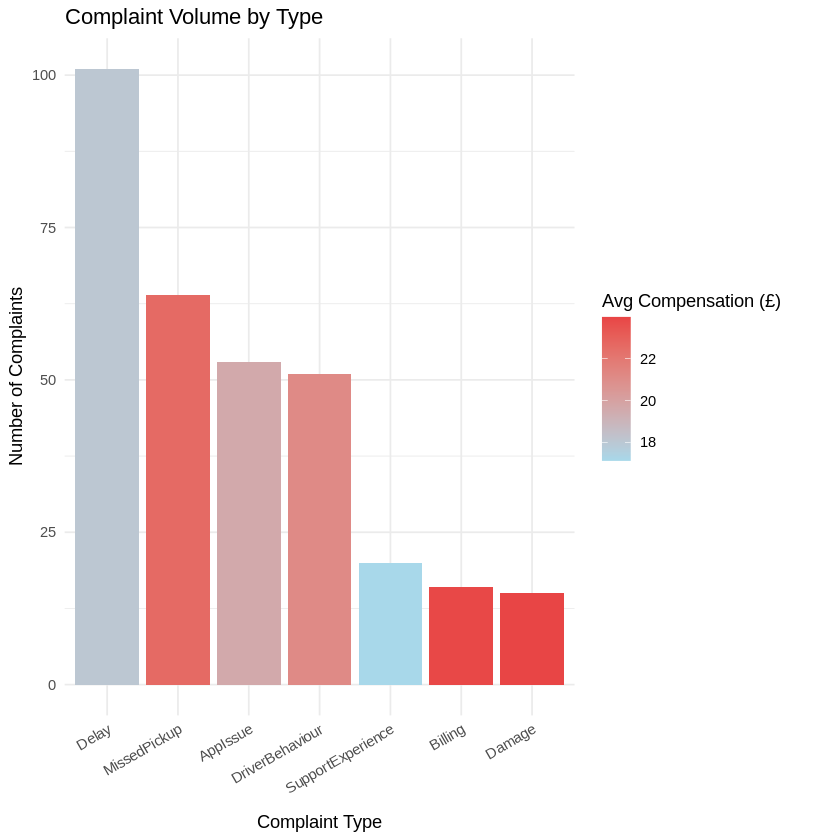

In [ ]:
ggplot(q3, aes(x = reorder(complaint_type, -total_complaints), y = total_complaints, fill = avg_compensation_gbp)) +
  geom_bar(stat = "identity") +
  scale_fill_gradient(low = "#a8d8ea", high = "#e84545") +
  labs(
    title = "Complaint Volume by Type",
    x     = "Complaint Type",
    y     = "Number of Complaints",
    fill  = "Avg Compensation (£)"
  ) +
  theme_minimal() +
  theme(axis.text.x = element_text(angle = 30, hjust = 1))

**4th QUERY: Average Order Value and Volume by Service Type**

Understanding which services generate the most revenue helps the finance director identify profitable vs loss-making service areas.

In [ ]:
q4 <- sqldf("
  SELECT
    service_type,
    COUNT(order_id) AS total_orders,
    ROUND(AVG(order_value), 2) AS avg_order_value,
    ROUND(SUM(order_value), 2) AS total_revenue
  FROM orders
  GROUP BY service_type
  ORDER BY total_revenue DESC
")

cat("\n Query 4: Order Volume and Revenue by Service Type \n\n")
print(q4)


 Query 4: Order Volume and Revenue by Service Type 

  service_type total_orders avg_order_value total_revenue
1    Passenger          341           96.07      32761.11
2       Parcel          308           87.62      26985.62
3       Retail          297           90.01      26734.06
4     Business          165           92.25      15220.43
5      Medical          139           87.14      12111.93


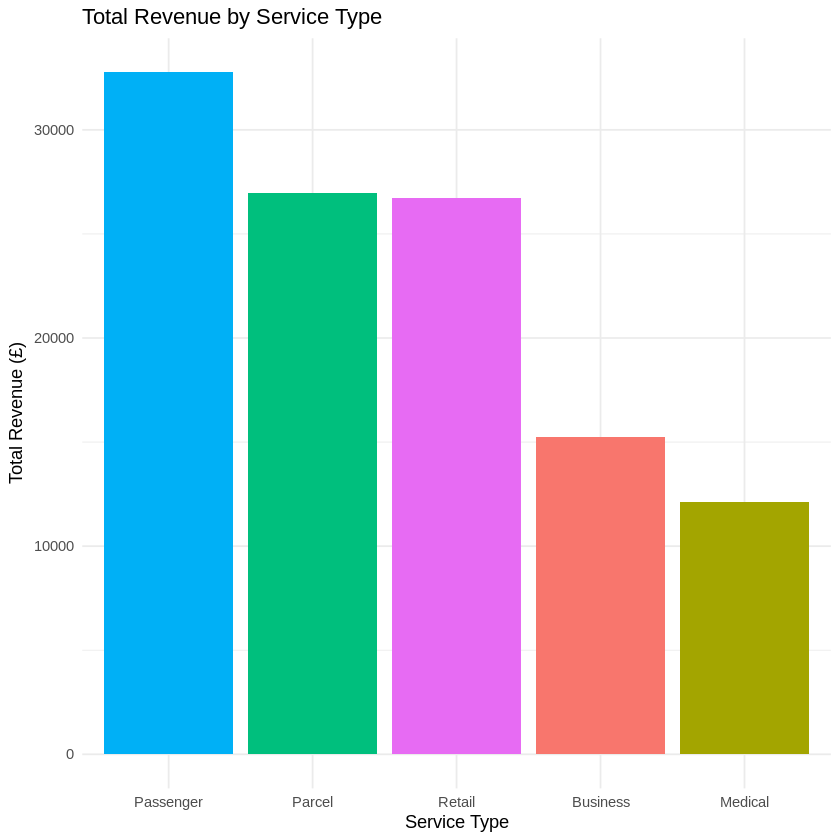

In [ ]:
ggplot(q4, aes(x = reorder(service_type, -total_revenue), y = total_revenue, fill = service_type)) +
  geom_bar(stat = "identity") +
  labs(
    title = "Total Revenue by Service Type",
    x     = "Service Type",
    y     = "Total Revenue (£)"
  ) +
  theme_minimal() +
  theme(legend.position = "none")

**5th QUERY: Hub Performance – Failure Rate and Manual Overrides**

Hubs with high failure rates and many manual route overrides may indicate planning or staffing problems.

In [ ]:
q5 <- sqldf("
  SELECT
    d.hub_id,
    COUNT(d.delivery_id) AS total_dispatches,
    SUM(CASE WHEN d.delivery_status = 'Failed'  THEN 1 ELSE 0 END) AS failed,
    SUM(CASE WHEN d.delivery_status = 'Delayed' THEN 1 ELSE 0 END) AS delayed,
    SUM(d.manual_route_override_count) AS total_overrides,
    ROUND(AVG(d.fuel_or_charge_cost), 2) AS avg_cost
  FROM deliveries d
  GROUP BY d.hub_id
  ORDER BY failed DESC
")

cat(" Query 5: Hub Performance Overview \n\n")
print(q5)

 Query 5: Hub Performance Overview 

  hub_id total_dispatches failed delayed total_overrides avg_cost
1    H08              128     26      22             142    11.71
2    H05              115     23      25             109    13.69
3    H01              136     17      26             140    12.76
4    H04              127     16      28             111    13.17
5    H06              104     15      27              95    13.32
6    H07              115     14      25             121    12.92
7    H03              119     11      23             106    12.74
8    H02              106     10      26              97    12.57


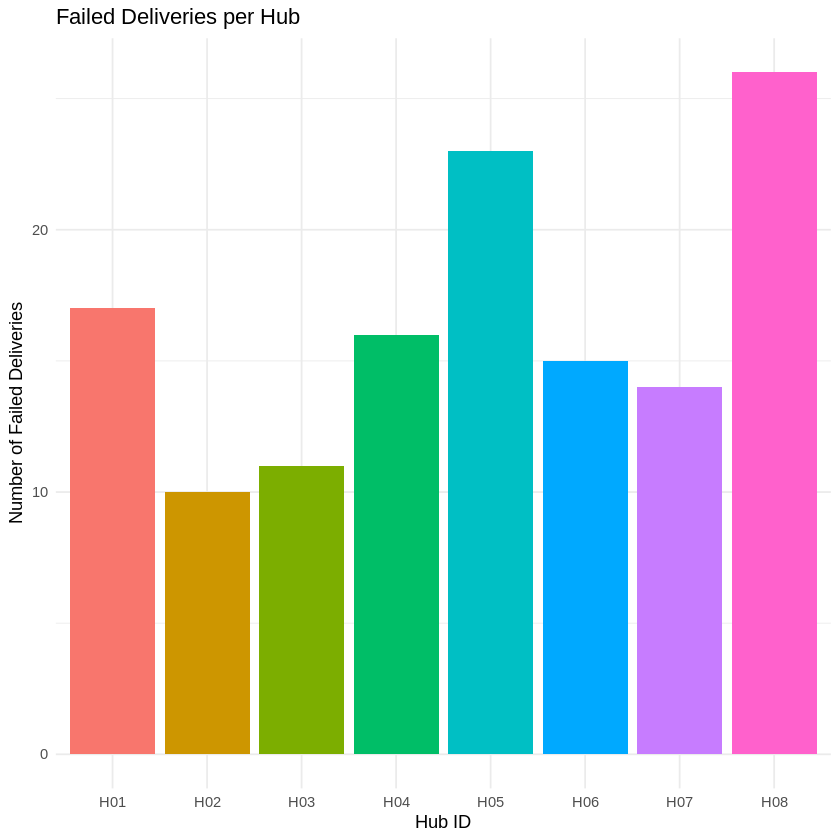

In [ ]:
ggplot(q5, aes(x = hub_id, y = failed, fill = hub_id)) +
  geom_bar(stat = "identity") +
  labs(
    title = "Failed Deliveries per Hub",
    x     = "Hub ID",
    y     = "Number of Failed Deliveries"
  ) +
  theme_minimal() +
  theme(legend.position = "none")

**6th QUERY: Customers with Repeat Complaints**

Customers who complain more than once may indicate systemic service failures rather than one-off issues.

In [ ]:
q6 <- sqldf("
  SELECT
    c.customer_id,
    cu.home_zone,
    cu.customer_type,
    cu.loyalty_score,
    COUNT(c.complaint_id) AS complaint_count,
    ROUND(SUM(c.compensation_amount), 2) AS total_compensation
  FROM complaints c
  JOIN customers cu ON c.customer_id = cu.customer_id
  GROUP BY c.customer_id
  HAVING complaint_count > 1
  ORDER BY complaint_count DESC
  LIMIT 15
")

cat("\n Query 6: Customers with Repeat Complaints \n\n")
print(q6)


 Query 6: Customers with Repeat Complaints 

   customer_id home_zone customer_type loyalty_score complaint_count
1        C0368     North      Consumer          49.5               4
2        C0626     South      Consumer          61.6               3
3        C0573   Airport           SME          57.3               3
4        C0545     South      Consumer          66.9               3
5        C0421   Central      Consumer          59.0               3
6        C0372      West      Consumer          26.2               3
7        C0282 RiverSide      Consumer          71.4               3
8        C0242      East      Consumer          83.8               3
9        C0191     North      Consumer          58.9               3
10       C0172     North      Consumer          75.4               3
11       C0142     South      Consumer          47.0               3
12       C0110      East      Consumer            NA               3
13       C0647      East      Consumer            NA     

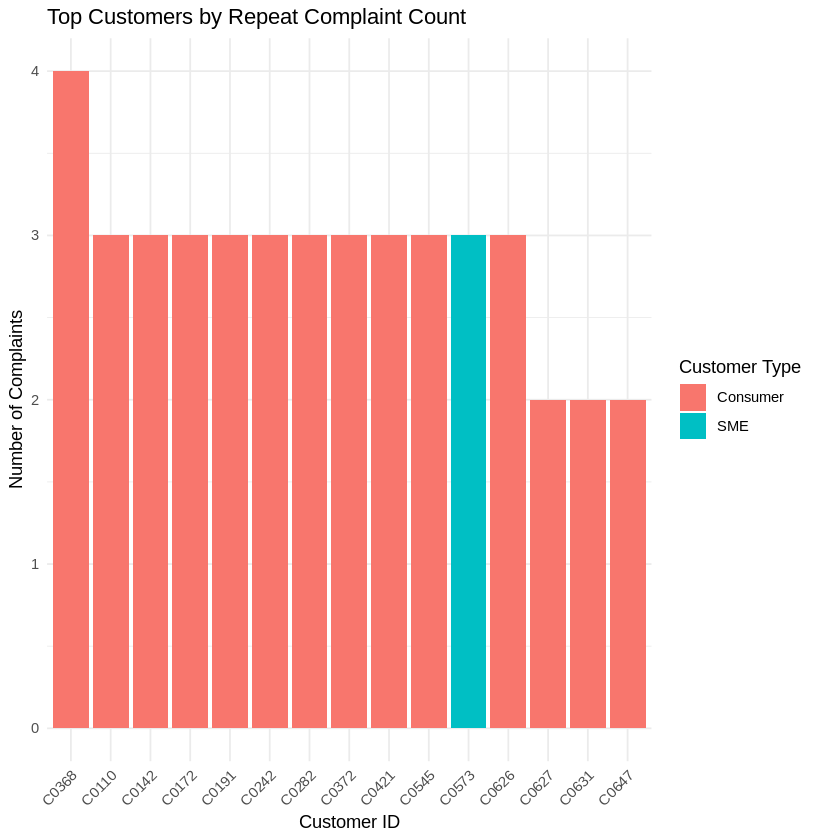

In [ ]:
ggplot(q6, aes(x = reorder(customer_id, -complaint_count), y = complaint_count, fill = customer_type)) +
  geom_bar(stat = "identity") +
  labs(
    title = "Top Customers by Repeat Complaint Count",
    x     = "Customer ID",
    y     = "Number of Complaints",
    fill  = "Customer Type"
  ) +
  theme_minimal() +
  theme(axis.text.x = element_text(angle = 45, hjust = 1))

**7th QUERY: Incident Severity vs Resolution Time**

Are high severity incidents being resolved faster than low severity ones? This checks if triage is working.

In [ ]:
q7 <- sqldf("
  SELECT
    severity,
    COUNT(incident_id) AS total_incidents,
    ROUND(AVG(resolved_hours), 2) AS avg_resolution_hours,
    SUM(CASE WHEN resolution_status = 'Open' THEN 1 ELSE 0 END) AS still_open,
    SUM(CASE WHEN resolution_status = 'Escalated' THEN 1 ELSE 0 END) AS escalated
  FROM incidents
  GROUP BY severity
  ORDER BY avg_resolution_hours DESC
")

cat("\n Query 7: Incident Resolution by Severity \n\n")
print(q7)


 Query 7: Incident Resolution by Severity 

  severity total_incidents avg_resolution_hours still_open escalated
1      Low              79                13.58         21         8
2   Medium             106                11.47         29        11
3 Critical              27                11.44          8         3
4     High              68                11.15         19        13


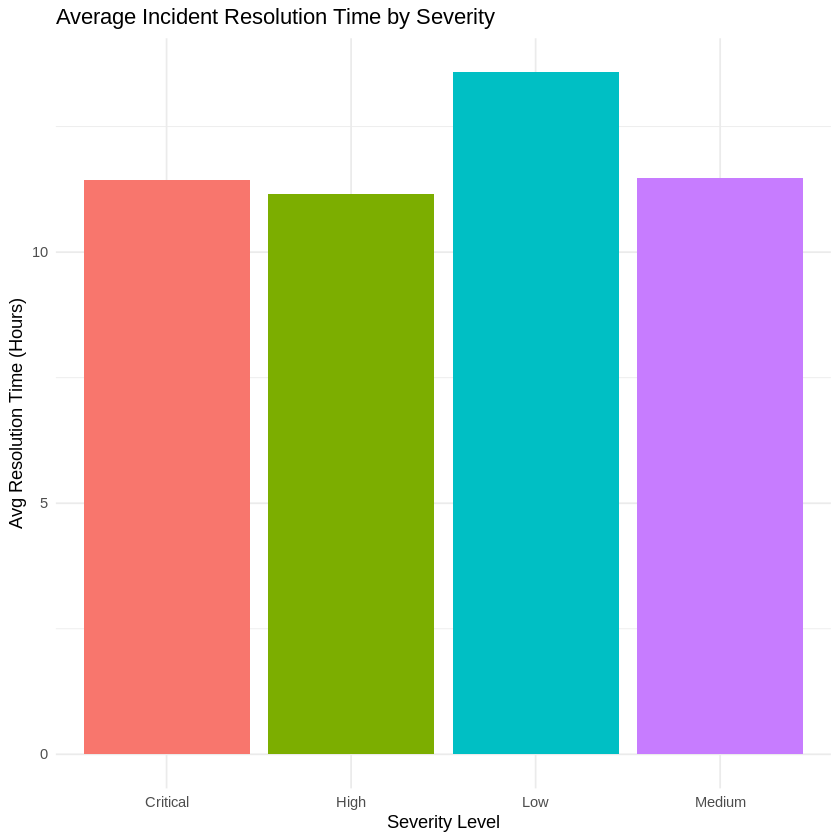

In [ ]:
ggplot(q7, aes(x = severity, y = avg_resolution_hours, fill = severity)) +
  geom_bar(stat = "identity") +
  labs(
    title = "Average Incident Resolution Time by Severity",
    x     = "Severity Level",
    y     = "Avg Resolution Time (Hours)"
  ) +
  theme_minimal() +
  theme(legend.position = "none")